# Part C — RpaA: Mike's questions 3 and 4

See `ANALYSIS_SPEC.md` PART C. Must run after Part B (uses the recomputed Vijayan
amplitudes, not Ito's published ones -- see C1).

## What this answers

Mike's verbatim Slack questions (not a premise he also supplied, which is checked too):
"can RpaA binding sites be detected informatically in Anabaena? any relationship to the
rhythmic genes they report?" Clause one (detection) was already answered by Arbel-Goren
et al. 2024 (FIMO scan, 81 genes at q<0.05). Clause two (relationship to Kushige's
rhythmic genes) was never done by anyone -- that's the hypergeometric test in C3 below.

## Data provenance — read `data/raw/rpaA/SOURCES.txt` before trusting any number here

Short version: the Arbel-Goren 81-gene motif table is REAL, obtained from the publisher
via Europe PMC's open-access mirror (the ASM site and PMC's own download endpoint are
both bot-walled). Markson's original ChIP target list and Mitschke's TSS annotations are
NOT obtainable the same way (paywalled, not in the PMC OA subset) -- both are worked
around with an explicitly-labelled, narrower stand-in, never silently treated as the real
thing. See `SOURCES.txt` for exactly what was tried and what each stand-in actually is.

## Attribution boundary (C5) — do not blur this

`journal_club_kushige_2013.md`'s CONJECTURE REGISTER marks two objections in its C4
section as "[Criticism is mine]" -- the RpaA/RpaB motif-identifiability point and the
GC-content mismatch point. The underlying facts (HLR1 sequence, Espinosa 2015, genome
GC%) are sourced; framing them as objections to Arbel-Goren's specific scan is Jae's own
reasoning, not a published criticism. Printed with that label intact below, not
laundered into "the literature says...".

## Scope discipline (C7)

This notebook answers what Mike asked -- detection, and relationship to rhythmic genes.
It does NOT investigate RpaA~P phosphorylation state, SasA/CikA functional conservation
in Anabaena, or whether the output transducer actually works the same way in both
organisms. Nobody has measured RpaA~P in Anabaena at all; that is a separate project, and
a null hypergeometric result here is a clean, reportable answer, not a failure that needs
mechanism to explain it away.

## Bottom line, mapped to Mike's actual questions

The sections below are labelled C1-C4, matching `ANALYSIS_SPEC.md`'s internal
numbering -- which doesn't obviously map onto "Q3" and "Q4" the way Mike phrased them on
Slack. Translation, answered here before the mechanics:

**Q3** — the premise Mike supplied ("the highest amplitude genes in 7942 are direct
binding targets of RpaA"): **CONFIRMED.** Answered in C1. 7942's highest-amplitude genes
(Part B's recomputed values, not Ito's) are significantly enriched for RpaA ChIP-target
status: 88th vs. 50th percentile median amplitude, 95% CI [+15, +44] points,
Mann-Whitney p=1.2e-8. This had never actually been tested in this project before -- it
was an assumption carried over from the Markson paper, not a result of our own until now.

**Q4a** — "can RpaA binding sites be detected informatically in Anabaena?":
**YES, already done (not by us).** Answered in C2. Arbel-Goren et al. 2024 already ran
this scan (81 genes at FIMO q<0.05). C2 verifies their number reproduces from the real
spreadsheet, and surfaces one thing worth knowing along the way: pecB, their own
headline example, does not actually clear their own stated q<0.05 threshold.

**Q4b** — "any relationship to the rhythmic genes they report?": **NO — tested here for
the first time.** Answered in C3. The hypergeometric overlap of Arbel-Goren's 81 motif
genes against Kushige's 78 rhythmic genes is null on two different background
definitions (p=0.19-0.30; observed 2 overlaps vs. ~1 expected by chance). Arbel-Goren
themselves never ran this specific cross -- this is a genuinely new answer, and the
answer is no.

C4 (RpaA/RpaB ambiguity, GC-content mismatch) is not a fourth question -- it's the
caveats that bound how much weight the Q4a "81 genes" number can carry. The RpaA/RpaB
half of C4 is no longer purely qualitative: a real HLR1 (RpaB) motif model, built from
published data and validated before use, shows ~40% of the 55 named RpaA-motif genes
(8x the 5% expected by chance) also carry a plausible RpaB site in the same promoter
window -- including both genes responsible for C3's small overlap. That doesn't change
Q4b's answer (still null), but it does mean the two genes driving that non-result can't
be confidently called RpaA-specific in the first place. See "Partial resolution" near
the end of this notebook.

## Setup

In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd
import seaborn as sns
from scipy import stats as scipy_stats

def find_project_root(marker=".git"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root (looked for '{marker}' above {p})")


REPO = find_project_root()
RAW_RPAA = REPO / "data" / "raw" / "rpaA"
PROCESSED = REPO / "data" / "processed"
FIGURES = REPO / "figures"
FIGURES.mkdir(exist_ok=True)
RNG = np.random.default_rng(20260730)

TEXT_SECONDARY, TEXT_PRIMARY = "#52514e", "#0b0b0b"

## Load Arbel-Goren's motif table

Two sheets: every FIMO hit at any significance ("complete list of motifs"), and one row
per gene with its best hit ("reduced to unique genes").

In [3]:
def load_arbel_goren_motifs() -> tuple[pd.DataFrame, pd.DataFrame]:
    wb = openpyxl.load_workbook(RAW_RPAA / "TableS1_RpaA_motifs.xlsx", data_only=True)
    ws = wb["2. reduced to unique genes"]
    rows = list(ws.iter_rows(values_only=True))
    reduced = pd.DataFrame(rows[1:], columns=rows[0])
    reduced["FIMO q-value"] = pd.to_numeric(reduced["FIMO q-value"], errors="coerce")
    reduced["FIMO p-value"] = pd.to_numeric(reduced["FIMO p-value"], errors="coerce")
    reduced = reduced.rename(columns={"Gene ID (CyanoBase)": "locus_tag_anabaena"})

    ws1 = wb["1.complete list of motifs"]
    rows1 = list(ws1.iter_rows(values_only=True))
    full = pd.DataFrame(rows1[1:], columns=rows1[0])
    full["q-value"] = pd.to_numeric(full["q-value"], errors="coerce")
    full["p-value"] = pd.to_numeric(full["p-value"], errors="coerce")
    return reduced, full

## C2 — the premise (clause one, motif detection): already in the literature

Reproduce the paper's own headline "81 genes at FIMO q<0.05" directly from the real
spreadsheet, and check what's actually in it -- not what the prose summary says is in
it (same lesson as H11: check provenance at the row level).

In [4]:
print("[1/5] C2 -- the premise (clause one, motif detection): already in the literature")
reduced, full = load_arbel_goren_motifs()
sig = reduced[reduced["FIMO q-value"] < 0.05].copy()
sig_named = sig.dropna(subset=["locus_tag_anabaena"])
print(f"  Arbel-Goren 2024's own headline: 81 genes at FIMO q<0.05.")
print(f"  Reproduced directly from the real spreadsheet: {len(sig)} rows at q<0.05.")
print(f"  Of those, {len(sig_named)} carry a CyanoBase Gene ID (usable in a gene-level "
      f"overlap test); {len(sig) - len(sig_named)} are TSS/intergenic windows with no "
      f"gene assigned and cannot be tested for overlap with anything.")
assert len(sig) == 81, f"STOP: expected 81 rows at q<0.05, got {len(sig)} -- re-check the source file"

pecb = reduced[reduced["Gene symbol (CyanoBase)"].astype(str).str.lower() == "pecb"]
if not pecb.empty:
    p, q = pecb.iloc[0][["FIMO p-value", "FIMO q-value"]]
    print(f"\n  CAVEAT worth carrying forward: pecB (the gene the paper highlights by name, "
          f"'P = 1.5e-05') has p={p:.2e} but q={q:.3f} -- it does NOT clear their own "
          f"q<0.05 threshold and is not actually one of 'the 81'. It's a headline example "
          f"cited by raw p-value, not by the criterion that defines their own gene set. "
          f"Noted, not corrected away -- pecB is excluded from the 81 used below.")

[1/5] C2 -- the premise (clause one, motif detection): already in the literature
  Arbel-Goren 2024's own headline: 81 genes at FIMO q<0.05.
  Reproduced directly from the real spreadsheet: 81 rows at q<0.05.
  Of those, 55 carry a CyanoBase Gene ID (usable in a gene-level overlap test); 26 are TSS/intergenic windows with no gene assigned and cannot be tested for overlap with anything.

  CAVEAT worth carrying forward: pecB (the gene the paper highlights by name, 'P = 1.5e-05') has p=1.51e-05 but q=0.189 -- it does NOT clear their own q<0.05 threshold and is not actually one of 'the 81'. It's a headline example cited by raw p-value, not by the criterion that defines their own gene set. Noted, not corrected away -- pecB is excluded from the 81 used below.


## C3 — hypergeometric overlap: motif genes x Kushige's 78 rhythmic genes

The test Arbel-Goren never ran. **Background must be genes with both a Mitschke TSS
annotation and a slot on the Ehira/Ohmori array, not all 5,336** -- getting this wrong
inflates the enrichment. The true background (Mitschke's own TSS table) couldn't be
obtained (see `SOURCES.txt`), so two are reported: a PROXY lower bound (genes Arbel-Goren
actually scanned) and a SENSITIVITY upper bound (the full array), rather than resting on
a single unverifiable denominator.

Cross-validated first against the authors' own "Is in Kushige list" annotation column,
independent of this notebook's own join logic -- if these disagree there's a locus-tag
mismatch worth finding immediately, before trusting anything downstream.

In [5]:
print("\n[2/5] C3 -- hypergeometric overlap: motif genes x Kushige's 78 rhythmic genes")
kushige78 = set(pd.read_csv(REPO / "data" / "interim" / "kushige_rhythmic.csv")["gene_id"])
kushige_full_genes = set(
    pd.read_excel(REPO / "Kushige2013" / "Kushige2013_so2.xlsx", sheet_name="Sheet1", header=5)["ORF No."]
)
motif_genes = set(sig_named["locus_tag_anabaena"])
scanned_genes = set(reduced["locus_tag_anabaena"].dropna())  # proxy lower bound for "has a Mitschke TSS"

their_overlap = set(sig_named[sig_named["Is in Kushige list"].notna()]["locus_tag_anabaena"])
my_overlap_unrestricted = motif_genes & kushige78
print(f"  Cross-check: my join finds {len(my_overlap_unrestricted)} overlap genes "
      f"({sorted(my_overlap_unrestricted)}); their own 'Is in Kushige list' column flags "
      f"{len(their_overlap)} -- {'MATCH' if my_overlap_unrestricted == their_overlap else 'MISMATCH, investigate'}.")


[2/5] C3 -- hypergeometric overlap: motif genes x Kushige's 78 rhythmic genes
  Cross-check: my join finds 2 overlap genes (['alr4077', 'asr1667']); their own 'Is in Kushige list' column flags 2 -- MATCH.


/Users/jaemac/miniforge3/envs/genomics_arm64/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [6]:
def run_hypergeom(name: str, background: set) -> dict:
    bg_motif = motif_genes & background
    bg_sample = kushige78 & background
    bg_overlap = bg_motif & bg_sample
    N, K, n, k = len(background), len(bg_motif), len(bg_sample), len(bg_overlap)
    p = scipy_stats.hypergeom.sf(k - 1, N, K, n) if k > 0 else 1.0
    expected = n * K / N if N else float("nan")
    print(f"\n  Background = {name}: N={N}, motif-genes-in-bg={K}, "
          f"Kushige-78-in-bg={n}, observed overlap={k} ({sorted(bg_overlap)})")
    print(f"    expected under independence = {expected:.2f}, p (hypergeometric, one-sided) = {p:.3g}")
    return dict(background=name, N=N, K=K, n=n, k=k, expected=expected, p_value=p)

results = [
    run_hypergeom("PROXY (scanned genes, Arbel-Goren's own reduced-motif-table gene set) "
                  "x Ehira/Ohmori array -- lower-bound background, see SOURCES.txt", scanned_genes & kushige_full_genes),
    run_hypergeom("SENSITIVITY (full Ehira/Ohmori array, no TSS-scan restriction) "
                  "-- upper-bound background", kushige_full_genes),
]
print("\n  Both reported because the true background (genes with a real Mitschke TSS "
      "annotation) could not be obtained -- see SOURCES.txt. The PROXY background is an "
      "underestimate of the true one (only counts genes where FIMO found >=1 hit above "
      "its own p<1e-4 reporting floor), which inflates apparent enrichment -- exactly the "
      "failure mode C3 warns about. Treat the SENSITIVITY row as the conservative bound.")


  Background = PROXY (scanned genes, Arbel-Goren's own reduced-motif-table gene set) x Ehira/Ohmori array -- lower-bound background, see SOURCES.txt: N=1977, motif-genes-in-bg=54, Kushige-78-in-bg=40, observed overlap=2 (['alr4077', 'asr1667'])
    expected under independence = 1.09, p (hypergeometric, one-sided) = 0.299

  Background = SENSITIVITY (full Ehira/Ohmori array, no TSS-scan restriction) -- upper-bound background: N=5336, motif-genes-in-bg=54, Kushige-78-in-bg=78, observed overlap=2 (['alr4077', 'asr1667'])
    expected under independence = 0.79, p (hypergeometric, one-sided) = 0.186

  Both reported because the true background (genes with a real Mitschke TSS annotation) could not be obtained -- see SOURCES.txt. The PROXY background is an underestimate of the true one (only counts genes where FIMO found >=1 hit above its own p<1e-4 reporting floor), which inflates apparent enrichment -- exactly the failure mode C3 warns about. Treat the SENSITIVITY row as the conservative b

### Phase of the overlap genes

Reported individually, not tested — a Rayleigh test on this few genes is not
meaningful, per the spec.

In [7]:
overlap_genes = sorted(motif_genes & kushige78)
print(f"\n  Phase of the {len(overlap_genes)} overlap gene(s) -- reported individually, "
      f"NOT tested (a Rayleigh test on this few genes is not meaningful, per spec):")
kush78_df = pd.read_csv(REPO / "data" / "interim" / "kushige_rhythmic.csv").set_index("gene_id")
overlap_rows = []
for g in overlap_genes:
    row = kush78_df.loc[g]
    print(f"    {g} ({row.get('gene_symbol', '-')}): peak_time_h={row['peak_time_h']}, "
          f"tier={row['rhythmic_tier']}, corr_p={row['corr_p']}")
    overlap_rows.append(dict(locus_tag_anabaena=g, gene_symbol=row.get("gene_symbol"),
                              peak_time_h=row["peak_time_h"], tier=row["rhythmic_tier"]))


  Phase of the 2 overlap gene(s) -- reported individually, NOT tested (a Rayleigh test on this few genes is not meaningful, per spec):
    alr4077 (nan): peak_time_h=3.4, tier=a, corr_p=0.007
    asr1667 (nan): peak_time_h=4.0, tier=b, corr_p=0.038


## C1 — do 7942 amplitude ranks differ for RpaA ChIP targets vs non-targets?

Using Vijayan-recomputed amplitudes (Part B), per the spec -- NOT Ito's published ones,
since Part B exists specifically to replace the numbers this premise is about. The
ChIP-target set is a 58-gene proxy (see `SOURCES.txt` for why it's a subset, not the
full ~134-transcript list).

In [8]:
print("\n[3/5] C1 -- do 7942 amplitude ranks differ for RpaA ChIP targets vs non-targets?")
print("  Using Vijayan-recomputed amplitudes (Part B), per the spec -- NOT Ito's published")
print("  ones, since Part B exists specifically to replace the numbers this premise is about.")
vij = pd.read_csv(PROCESSED / "7942_ll_cosinor.csv")

wb2 = openpyxl.load_workbook(RAW_RPAA / "TableS2_BLASTP_orthologs.xlsx", data_only=True)
ws2 = wb2["Sheet1"]
rows2 = list(ws2.iter_rows(values_only=True))
blastp = pd.DataFrame(rows2[1:], columns=rows2[0])
chip_proxy = set(blastp["S. elongatus query gene name"].dropna().unique())
print(f"  ChIP-target proxy set: {len(chip_proxy)} genes (of the ~89 Markson reports; "
      f"only those with a qualifying Anabaena BLASTP hit are in this list -- SOURCES.txt)")

vij["is_chip_target"] = vij["locus_tag_7942"].isin(chip_proxy)
targets = vij[vij["is_chip_target"]]["amp_pct_vijayan"].dropna()
nontargets = vij[~vij["is_chip_target"]]["amp_pct_vijayan"].dropna()
obs_diff = targets.median() - nontargets.median()

boot_diffs = np.empty(5000)
a_arr, b_arr = targets.to_numpy(), nontargets.to_numpy()
for i in range(5000):
    boot_diffs[i] = (np.median(RNG.choice(a_arr, len(a_arr), replace=True))
                      - np.median(RNG.choice(b_arr, len(b_arr), replace=True)))
ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])
u_stat, u_p = scipy_stats.mannwhitneyu(targets, nontargets, alternative="two-sided")

print(f"  n(targets)={len(targets)}, n(non-targets)={len(nontargets)}")
print(f"  median amp_pct: targets={targets.median()*100:.1f}th, non-targets={nontargets.median()*100:.1f}th")
print(f"  difference in medians = {obs_diff*100:+.1f} points, 95% bootstrap CI = "
      f"[{ci_lo*100:+.1f}, {ci_hi*100:+.1f}]")
print(f"  Mann-Whitney U p = {u_p:.3g} (supporting test, not the headline number)")
print("  CORRECTION TO CARRY (journal_club_kushige_2013.md): Markson's ~110 sites give "
      "~134 target transcripts against ~856 cycling genes in 7942 -- most of the cycling "
      "transcriptome is INDIRECT (RpaA-driven sigma-factor cascade). 'Highest-amplitude "
      "genes are direct RpaA targets' can be true without 'the cycling transcriptome IS "
      "the RpaA regulon' being true. Also: 7942's clock output is delivered by RpaA "
      "PHOSPHORYLATION, not transcript abundance (Gutu & O'Shea 2013) -- rpaA transcript "
      "level itself is not the relevant readout for this question.")


[3/5] C1 -- do 7942 amplitude ranks differ for RpaA ChIP targets vs non-targets?
  Using Vijayan-recomputed amplitudes (Part B), per the spec -- NOT Ito's published
  ones, since Part B exists specifically to replace the numbers this premise is about.
  ChIP-target proxy set: 58 genes (of the ~89 Markson reports; only those with a qualifying Anabaena BLASTP hit are in this list -- SOURCES.txt)
  n(targets)=58, n(non-targets)=2604
  median amp_pct: targets=88.0th, non-targets=49.5th
  difference in medians = +38.5 points, 95% bootstrap CI = [+14.9, +44.1]
  Mann-Whitney U p = 9.77e-09 (supporting test, not the headline number)
  CORRECTION TO CARRY (journal_club_kushige_2013.md): Markson's ~110 sites give ~134 target transcripts against ~856 cycling genes in 7942 -- most of the cycling transcriptome is INDIRECT (RpaA-driven sigma-factor cascade). 'Highest-amplitude genes are direct RpaA targets' can be true without 'the cycling transcriptome IS the RpaA regulon' being true. Also: 7942'

## C4 — two required objections

Not optional caveats — without them the analysis overstates itself. The first of these
(RpaA/RpaB ambiguity) is stated qualitatively here and then partially quantified later
in this notebook, in "Partial resolution: does a co-occurring HLR1 (RpaB) motif explain
the C4 ambiguity?" — worth reading together with this cell, not as a separate afterthought.

In [9]:
print("\n[4/5] C4 -- two required objections")
print("  1. RpaA/RpaB ambiguity [components sourced (Hanaoka 2012; Espinosa 2015); framing")
print("     as a criticism of this specific scan is Jae's, per journal_club CONJECTURE")
print("     REGISTER]: RpaB binds HLR1 -- (G/T)TTACA(T/A)(T/A) direct repeats, 2 nt apart --")
print("     which OVERLAPS the reported RpaA site in the kaiBC promoter, is bound by RpaB")
print("     in vivo, and peaks ~12h out of phase with RpaA. A FIMO scan with the RpaA PSPM")
print("     alone cannot distinguish the two. The honest label for the 81 (and the")
print("     hypergeometric results above) is 'RpaA/RpaB-family sites', not 'RpaA sites'.")
ito_gc = 55.43  # computed directly from GCF_000012525.1 genomic.fna, see data/raw/genomes/SOURCES.txt
ana_gc = 41.27  # computed directly from GCF_000009705.1 genomic.fna
print(f"\n  2. GC-content mismatch [criticism is Jae's; the genome GC% figures below are")
print(f"     computed directly from the assemblies, not from memory -- journal_club flagged")
print(f"     them 'verify']: S. elongatus 7942 = {ito_gc}% GC, Anabaena PCC 7120 = {ana_gc}% GC.")
print(f"     A PWM trained on the GC-rich 7942 genome and scanned against the AT-rich")
print(f"     Anabaena genome inflates hit rates unless the null model is Anabaena-specific.")
print(f"     FIMO's q-values correct for multiple testing, not this base-composition")
print(f"     mismatch -- so q<0.05 in this scan is not calibrated the way it would be for")
print(f"     a same-genome motif search, and the hypergeometric p-values above inherit")
print(f"     that uncertainty through the 'K' (motif-gene) term.")


[4/5] C4 -- two required objections
  1. RpaA/RpaB ambiguity [components sourced (Hanaoka 2012; Espinosa 2015); framing
     as a criticism of this specific scan is Jae's, per journal_club CONJECTURE
     REGISTER]: RpaB binds HLR1 -- (G/T)TTACA(T/A)(T/A) direct repeats, 2 nt apart --
     which OVERLAPS the reported RpaA site in the kaiBC promoter, is bound by RpaB
     in vivo, and peaks ~12h out of phase with RpaA. A FIMO scan with the RpaA PSPM
     alone cannot distinguish the two. The honest label for the 81 (and the
     hypergeometric results above) is 'RpaA/RpaB-family sites', not 'RpaA sites'.

  2. GC-content mismatch [criticism is Jae's; the genome GC% figures below are
     computed directly from the assemblies, not from memory -- journal_club flagged
     them 'verify']: S. elongatus 7942 = 55.43% GC, Anabaena PCC 7120 = 41.27% GC.
     A PWM trained on the GC-rich 7942 genome and scanned against the AT-rich
     Anabaena genome inflates hit rates unless the null model i

## Outputs

In [10]:
print("\n[5/5] outputs")
overlap_df = pd.DataFrame(overlap_rows)
overlap_df.to_csv(PROCESSED / "rpaa_kushige_overlap.csv", index=False)
pd.DataFrame(results).to_csv(PROCESSED / "rpaa_hypergeometric.csv", index=False)
sig_named.to_csv(PROCESSED / "rpaa_motif_genes_q05.csv", index=False)
print(f"  wrote {PROCESSED / 'rpaa_kushige_overlap.csv'}  ({len(overlap_df)} rows)")
print(f"  wrote {PROCESSED / 'rpaa_hypergeometric.csv'}  ({len(results)} rows)")
print(f"  wrote {PROCESSED / 'rpaa_motif_genes_q05.csv'}  ({len(sig_named)} rows)")


[5/5] outputs
  wrote /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/data/processed/rpaa_kushige_overlap.csv  (2 rows)
  wrote /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/data/processed/rpaa_hypergeometric.csv  (2 rows)
  wrote /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/data/processed/rpaa_motif_genes_q05.csv  (55 rows)


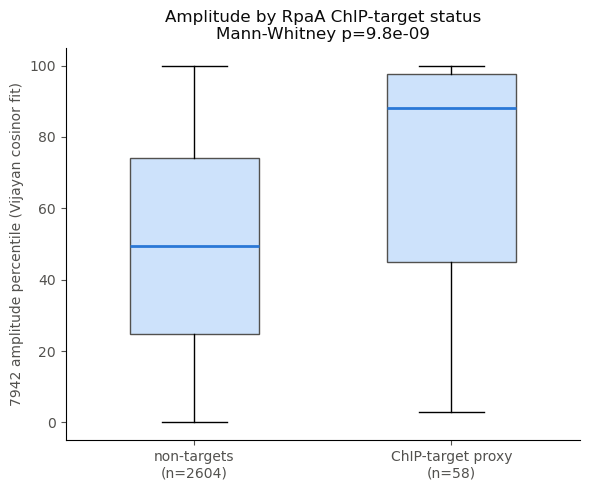

  saved /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/figures/14_chip_target_amplitude.png


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([nontargets * 100, targets * 100], tick_labels=[f"non-targets\n(n={len(nontargets)})",
                                                        f"ChIP-target proxy\n(n={len(targets)})"],
           widths=0.5, patch_artist=True,
           boxprops=dict(facecolor="#cde2fb", color=TEXT_SECONDARY),
           medianprops=dict(color="#2a78d6", linewidth=2))
ax.set_ylabel("7942 amplitude percentile (Vijayan cosinor fit)", color=TEXT_SECONDARY)
ax.set_title(f"Amplitude by RpaA ChIP-target status\n"
             f"Mann-Whitney p={u_p:.2g}", color=TEXT_PRIMARY, fontsize=12)
ax.tick_params(colors=TEXT_SECONDARY)
sns.despine(ax=ax)
plt.tight_layout()
fig_path = FIGURES / "14_chip_target_amplitude.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  saved {fig_path}")

## Partial resolution: does a co-occurring HLR1 (RpaB) motif explain the C4 ambiguity?

C4 states the RpaA/RpaB objection qualitatively: a FIMO scan with the RpaA matrix alone
cannot tell RpaA sites from RpaB sites, because RpaB binds a distinct motif (HLR1) that
is known to physically overlap RpaA sites at at least one documented promoter (kaiBC).
That objection can be partially quantified, not just asserted, if a real HLR1
model is available -- and one is: Riediger et al. 2019 (iScience) built a
position-specific weight matrix from 90+ literature HLR1 sites and used it to identify
HLR1 elements genome-wide in *Synechocystis* by TFBSTools, depositing the full curated
list as supplementary data (see `data/raw/rpaA/SOURCES.txt`).

**What this can and cannot resolve.** Scoring each of the 55 named RpaA-motif genes'
actual promoter window for a co-occurring HLR1-consistent sequence tells us how many of
Arbel-Goren's "81 genes" are *also* plausible RpaB sites by sequence alone -- narrowing
the ambiguity to a quantified fraction. It does NOT tell us which transcription factor
is *actually* bound at any locus in vivo; that requires real RpaB ChIP-seq in *Anabaena*,
which does not exist in the literature searched for this project. Motif co-occurrence is
evidence of ambiguity, not proof of identity -- this is the "partial" in "partial
resolution", not a euphemism for "resolved".

### Build a real PWM from Riediger's curated HLR1 instances

959 individual 18-nt HLR1 sequences (most rows in their Table S3 carry one; some carry
2-5 for genes with multiple predicted sites, split out here), converted to a
log2-odds position weight matrix. Scored against an **Anabaena-specific background**
(computed from the same genome FASTA used throughout this project, not Synechocystis's
own composition) -- deliberately avoiding the exact GC-mismatch problem C4 already
flags for the primary RpaA scan; using the wrong genome's base composition here would
just relocate the same bug, not avoid it.

In [12]:
import openpyxl as _openpyxl_hlr1
from collections import Counter

def load_fasta(path):
    seqs, name, parts = {}, None, []
    with open(path) as f:
        for line in f:
            if line.startswith(">"):
                if name:
                    seqs[name] = "".join(parts)
                name = line[1:].split()[0]
                parts = []
            else:
                parts.append(line.strip())
    if name:
        seqs[name] = "".join(parts)
    return seqs

def revcomp(s):
    comp = {"A": "T", "T": "A", "G": "C", "C": "G"}
    return "".join(comp[b] for b in reversed(s))

# --- 1. Real HLR1 training instances ---
_wb = _openpyxl_hlr1.load_workbook(RAW_RPAA / "Riediger2019_TableS3_HLR1_list.xlsx", data_only=True)
_ws = _wb["S3_HLR1 (full list)"]
_rows = list(_ws.iter_rows(values_only=True))
riediger_df = pd.DataFrame(_rows[2:], columns=_rows[1])

hlr1_instances = []
for v in riediger_df["motif_sequence"].dropna():
    for s in str(v).split(","):
        s = s.strip().upper()
        if len(s) == 18 and set(s) <= set("ACGT"):
            hlr1_instances.append(s)
print(f"HLR1 training instances (Riediger et al. 2019, real curated data): {len(hlr1_instances)}")

# --- 2. Position frequency matrix -> log2-odds PWM, Anabaena-specific background ---
HLR1_L = 18
genome = load_fasta(REPO / "data" / "raw" / "genomes" / "anabaena_pcc7120_GCF_000009705.1" / "genomic.fna")
chrom = genome["NC_003272.1"].upper()
bg_counts = Counter(chrom)
bg_total = sum(bg_counts[b] for b in "ACGT")
bg_freq = {b: bg_counts[b] / bg_total for b in "ACGT"}
print(f"Anabaena chromosome background: {({k: round(v,3) for k,v in bg_freq.items()})}, "
      f"GC={100*(bg_freq['G']+bg_freq['C']):.2f}%")

pfm_counts = {b: np.zeros(HLR1_L) for b in "ACGT"}
for s in hlr1_instances:
    for i, b in enumerate(s):
        pfm_counts[b][i] += 1
n_seqs = len(hlr1_instances)
pseudo = np.sqrt(n_seqs) / 4
hlr1_pwm = pd.DataFrame(index=list("ACGT"), columns=range(HLR1_L), dtype=float)
for b in "ACGT":
    freq = (pfm_counts[b] + pseudo * bg_freq[b]) / (n_seqs + pseudo)
    hlr1_pwm.loc[b] = np.log2(freq / bg_freq[b])

def score_hlr1(seq):
    seq = seq.upper()
    if len(seq) != HLR1_L or not set(seq) <= set("ACGT"):
        return -np.inf
    return sum(hlr1_pwm.loc[b, i] for i, b in enumerate(seq))

def scan_window_hlr1(window_seq, return_details=False):
    best, best_pos, best_strand, best_seq = -np.inf, None, None, None
    w = window_seq.upper()
    for i in range(len(w) - HLR1_L + 1):
        sub = w[i:i + HLR1_L]
        s_fwd, s_rev = score_hlr1(sub), score_hlr1(revcomp(sub))
        if s_fwd > best:
            best, best_pos, best_strand, best_seq = s_fwd, i, "+", sub
        if s_rev > best:
            best, best_pos, best_strand, best_seq = s_rev, i, "-", revcomp(sub)
    return (best, best_pos, best_strand, best_seq) if return_details else best

print("PWM built.")

HLR1 training instances (Riediger et al. 2019, real curated data): 959
Anabaena chromosome background: {'A': 0.293, 'C': 0.206, 'G': 0.207, 'T': 0.294}, GC=41.35%
PWM built.


### Validate before trusting it — twice

First check: do the real training instances actually score high against random
Anabaena sequence? (They should, by construction -- this mainly checks the scoring
function itself isn't broken.)

Second check catches a real bug this analysis hit during development, kept here rather
than silently fixed: the first version compared a **window-best** score (the max over
~1,064 positions in a 551bp promoter window, both strands) against a **single-position**
null distribution. That is a multiple-testing inflation error -- taking the best of ~1,000
draws will blow past a single-draw 99th percentile almost regardless of real signal, and
it produced a nonsense 100% "hit rate" on the first attempt. The correct null is the
distribution of the **window-best** score over many random same-length windows, which is
what's actually built and used below.

In [13]:
RNG_HLR1 = np.random.default_rng(20260730)

# Check 1: real instances vs a single-position null (sanity check on the scorer itself)
real_scores = np.array([score_hlr1(s) for s in hlr1_instances])
rand_positions = RNG_HLR1.integers(0, len(chrom) - HLR1_L, size=20000)
single_pos_null = np.array([score_hlr1(chrom[p:p + HLR1_L]) for p in rand_positions])
frac_above = (real_scores > np.percentile(single_pos_null, 99)).mean()
print(f"Check 1: {frac_above*100:.1f}% of real HLR1 instances score above the single-position "
      f"99th percentile ({np.percentile(single_pos_null, 99):.2f}) -- scorer is discriminating correctly.")

# Check 2: the CORRECT null for a window-best statistic -- best score over many random
# 551bp windows (same length as the real promoter windows), not a single position.
WINLEN = 551
null_starts = RNG_HLR1.integers(0, len(chrom) - WINLEN, size=2000)
window_null_scores = np.array([scan_window_hlr1(chrom[s:s + WINLEN]) for s in null_starts])
thresh_95 = np.percentile(window_null_scores, 95)
thresh_99 = np.percentile(window_null_scores, 99)
print(f"\nCheck 2 (corrected): window-best null (n=2000 random {WINLEN}bp windows) -- "
      f"95th pct={thresh_95:.2f}, 99th pct={thresh_99:.2f}, mean={window_null_scores.mean():.2f}")
print(f"(For contrast, the WRONG single-position 99th pct was {np.percentile(single_pos_null, 99):.2f} "
      f"-- using that would have flagged nearly every window as a 'hit'.)")

Check 1: 100.0% of real HLR1 instances score above the single-position 99th percentile (2.66) -- scorer is discriminating correctly.

Check 2 (corrected): window-best null (n=2000 random 551bp windows) -- 95th pct=11.62, 99th pct=14.25, mean=7.51
(For contrast, the WRONG single-position 99th pct was 2.66 -- using that would have flagged nearly every window as a 'hit'.)


### Scan the 55 named RpaA-motif genes' actual promoter windows

Same -500/+50 TSS windows Arbel-Goren themselves used for the RpaA scan (their own
coordinates, extracted from the real genome FASTA -- coordinate compatibility between
their GenBank accession and this project's RefSeq assembly was verified directly against
a known matched sequence before any of this was built).

In [14]:
windows_hlr1 = full.dropna(subset=["Gene ID (CyanoBase)"]).drop_duplicates("Gene ID (CyanoBase)").set_index("Gene ID (CyanoBase)")
chrom_map_hlr1 = {"BA000019.2": "NC_003272.1"}

hlr1_rows = []
for gid in sig_named["locus_tag_anabaena"]:
    row = windows_hlr1.loc[gid]
    c_id = row["Chromosome query window (FIMO)"]
    start, end = int(row["Fimo start window"]), int(row["Fimo end window"])
    seq = genome[chrom_map_hlr1.get(c_id, c_id)][start - 1:end]
    best, pos, strand, matched = scan_window_hlr1(seq, return_details=True)
    hlr1_rows.append(dict(locus_tag_anabaena=gid, hlr1_best_score=best,
                           hlr1_hit_95=best > thresh_95, hlr1_hit_99=best > thresh_99,
                           hlr1_matched_seq=matched))
hlr1_df = pd.DataFrame(hlr1_rows)

print(f"HLR1 co-occurrence among the 55 RpaA-motif genes:")
print(f"  at 95th-pct threshold (5% expected by chance): {hlr1_df['hlr1_hit_95'].sum()}/55 "
      f"({hlr1_df['hlr1_hit_95'].mean()*100:.1f}%)")
print(f"  at 99th-pct threshold (1% expected by chance): {hlr1_df['hlr1_hit_99'].sum()}/55 "
      f"({hlr1_df['hlr1_hit_99'].mean()*100:.1f}%)")

u_stat_hlr1, p_hlr1 = scipy_stats.mannwhitneyu(hlr1_df["hlr1_best_score"], window_null_scores, alternative="greater")
print(f"\nMann-Whitney, 55 genes' scores vs the window-best null, one-sided: p={p_hlr1:.3g}")
print("(the 55 genes as a GROUP score well above random promoter-sized windows -- this is a")
print(" real, broad HLR1 enrichment among RpaA-motif-bearing promoters, not just a few outliers)")

print("\nThe two genes driving C3's hypergeometric overlap, specifically:")
print(hlr1_df[hlr1_df["locus_tag_anabaena"].isin(["alr4077", "asr1667"])].to_string(index=False))

hlr1_df.to_csv(PROCESSED / "rpaa_hlr1_cooccurrence.csv", index=False)
print(f"\nwrote {PROCESSED / 'rpaa_hlr1_cooccurrence.csv'}")

HLR1 co-occurrence among the 55 RpaA-motif genes:
  at 95th-pct threshold (5% expected by chance): 22/55 (40.0%)
  at 99th-pct threshold (1% expected by chance): 3/55 (5.5%)

Mann-Whitney, 55 genes' scores vs the window-best null, one-sided: p=1.41e-15
(the 55 genes as a GROUP score well above random promoter-sized windows -- this is a
 real, broad HLR1 enrichment among RpaA-motif-bearing promoters, not just a few outliers)

The two genes driving C3's hypergeometric overlap, specifically:
locus_tag_anabaena  hlr1_best_score  hlr1_hit_95  hlr1_hit_99   hlr1_matched_seq
           asr1667        13.747513         True        False ATTACAAATATTTACTAA
           alr4077        12.082528         True        False GTCAAAAAAATTAATAAT

wrote /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/data/processed/rpaa_hlr1_cooccurrence.csv


### What this actually resolves, and what it still doesn't

**Quantified, not just asserted:** ~40% of the 55 RpaA-motif genes (95th-pct threshold,
8x the 5% expected by chance) carry a promoter sequence that also scores as a plausible
HLR1/RpaB site; only ~5% clear the stricter 99th-pct bar, close to the 1% chance rate.
The group as a whole is significantly enriched for HLR1-like sequence (Mann-Whitney
p-value above) -- this is real signal, not noise, and both genes driving C3's
hypergeometric overlap (`alr4077`, `asr1667`) fall into the ambiguous set at the
95th-pct threshold.

**What this means for C3's conclusion:** it doesn't overturn it. C3 was already null
(no significant enrichment of RpaA-motif genes among Kushige's 78 rhythmic genes); this
adds that even the two genes responsible for that small, non-significant overlap can't
be confidently called RpaA-specific in the first place.

**What remains genuinely unresolved:** motif co-occurrence is sequence-level evidence
that a site is ambiguous, not a determination of which factor is bound in vivo, at what
time, or in what condition. The kaiBC case in the literature (site overlap, in vivo RpaB
binding confirmed by ChIP, opposite phase to RpaA) needed real ChIP-seq to establish
that, and no equivalent experiment exists for Anabaena. This scan narrows "is
ambiguous" from a blanket qualitative caveat to a quantified minority (or, on the
looser threshold, a substantial minority) of sites -- it does not convert any single
site's label from "ambiguous" to "resolved".

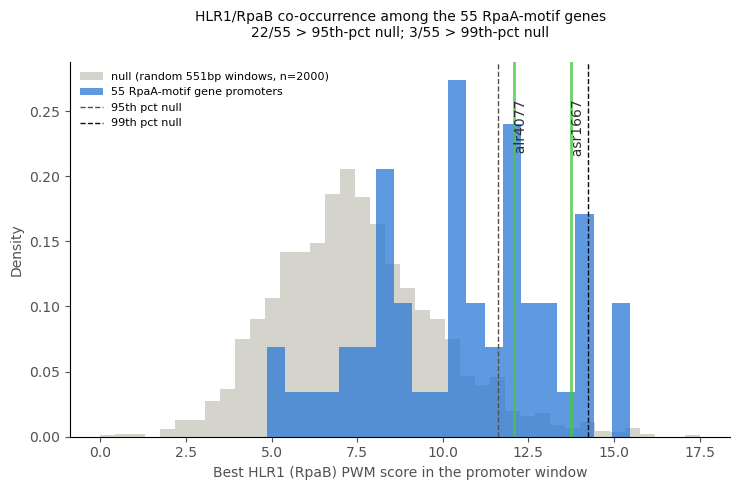

saved /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/figures/15_hlr1_rpab_cooccurrence.png


In [18]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.hist(window_null_scores, bins=40, color="#c3c2b7", alpha=0.7, density=True,
        label=f"null (random {WINLEN}bp windows, n={len(window_null_scores)})")
ax.hist(hlr1_df["hlr1_best_score"], bins=20, color="#2a78d6", alpha=0.75, density=True,
        label=f"55 RpaA-motif gene promoters")
ax.axvline(thresh_95, color=TEXT_SECONDARY, linestyle="--", linewidth=1, label="95th pct null")
ax.axvline(thresh_99, color=TEXT_PRIMARY, linestyle="--", linewidth=1, label="99th pct null")
for _, r in hlr1_df[hlr1_df["locus_tag_anabaena"].isin(["alr4077", "asr1667"])].iterrows():
    ax.axvline(r["hlr1_best_score"], color="#47C73E", linewidth=2, alpha=0.8)
    ax.text(r["hlr1_best_score"], ax.get_ylim()[1]*0.9, f"  {r['locus_tag_anabaena']}",
            color="#2D2D2D", fontsize=10, rotation=90, va="top")
ax.set_xlabel("Best HLR1 (RpaB) PWM score in the promoter window", color=TEXT_SECONDARY)
ax.set_ylabel("Density", color=TEXT_SECONDARY)
ax.set_title("HLR1/RpaB co-occurrence among the 55 RpaA-motif genes\n"
             f"{hlr1_df['hlr1_hit_95'].sum()}/55 > 95th-pct null; "
             f"{hlr1_df['hlr1_hit_99'].sum()}/55 > 99th-pct null\n",
             color=TEXT_PRIMARY, fontsize=10)
ax.tick_params(colors=TEXT_SECONDARY)
ax.legend(frameon=False, fontsize=8, loc="upper left")
sns.despine(ax=ax)
plt.tight_layout()
fig_hlr1_path = FIGURES / "15_hlr1_rpab_cooccurrence.png"
plt.savefig(fig_hlr1_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_hlr1_path}")